# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn

# Get the dataset from Google Drive

This dataset contains measurements from Alcator C-Mod interpolated onto a 10 ms timebase. Each row corresponds to a single time point in a discharge, with plasma parameters and density limit phase label. This dataset is a subset of the experimental catalogue and does not represent the full C-Mod database. Future releases will include more discharges.

Features
The dataset includes the following columns:

discharge_ID: Unique identifier for each discharge.

time: Time point within the discharge. Early time points when the experiment is ramping up are excluded.

density_limit_phase (target variable): Label indicating whether the time point is before (0) or during (1) the precursor density limit instability. Although the "density limit" is a complex phenomenon, we simplify the problem to binary labels: "before" (0) or "during" (1) the precursor phase of the density limit.

density: The average density of electrons in the plasma. Units:
$10^(20) m^(-3)$

elongation: How vertically elongated the plasma is. A value of 1 indicates a circular plasma, greater than 1 indicates the plasma is more tall than it is wide.

minor_radius: Minor radius of the plasma (the smaller radius in a toroidal geometry). Units: meters

plasma_current: Current flowing through the plasma. Units: Mega-Amperes (MA)

toroidal_B_field: Magnetic field strength in the toroidal direction. Units: Tesla (T)

triangularity: Shape parameter indicating how triangular the plasma cross-section is.

Reference: https://github.com/MIT-PSFC/open_density_limit_database

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = '/content/drive/MyDrive/Plasma Density Limit Dataset/Open_Density_Limit_Dataset.csv'
df = pd.read_csv(file_path)

df.head()

,discharge_ID,time,density_limit_phase,density,elongation,minor_radius,plasma_current,toroidal_B_field,triangularity
0,1000606012,0.26,0,1.068483,1.596838,0.215675,0.732045,5.375454,0.366888
1,1000606012,0.27,0,1.072965,1.624681,0.214933,0.742422,5.375454,0.379412
2,1000606012,0.28,0,1.077447,1.652525,0.214190,0.752798,5.375454,0.391936
3,1000606012,0.29,0,1.126277,1.662114,0.212518,0.760581,5.375454,0.392512
4,1000606012,0.30,0,1.175108,1.671703,0.210845,0.768363,5.375454,0.393087


In [4]:
print(df.columns)
print(df.head())
print(df.shape)

Index(['discharge_ID', 'time', 'density_limit_phase', 'density', 'elongation',
       'minor_radius', 'plasma_current', 'toroidal_B_field', 'triangularity'],
      dtype='object')
   discharge_ID  time  density_limit_phase   density  elongation  \
0    1000606012  0.26                    0  1.068483    1.596838   
1    1000606012  0.27                    0  1.072965    1.624681   
2    1000606012  0.28                    0  1.077447    1.652525   
3    1000606012  0.29                    0  1.126277    1.662114   
4    1000606012  0.30                    0  1.175108    1.671703   

   minor_radius  plasma_current  toroidal_B_field  triangularity  
0      0.215675        0.732045          5.375454       0.366888  
1      0.214933        0.742422          5.375454       0.379412  
2      0.214190        0.752798          5.375454       0.391936  
3      0.212518        0.760581          5.375454       0.392512  
4      0.210845        0.768363          5.375454       0.393087  
(264385, 

# Data Cleaning

In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
print(df.info())

Shape: (264385, 9)

Columns:
['discharge_ID', 'time', 'density_limit_phase', 'density', 'elongation', 'minor_radius', 'plasma_current', 'toroidal_B_field', 'triangularity']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264385 entries, 0 to 264384
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   discharge_ID         264385 non-null  int64  
 1   time                 264385 non-null  float64
 2   density_limit_phase  264385 non-null  int64  
 3   density              264385 non-null  float64
 4   elongation           264385 non-null  float64
 5   minor_radius         264385 non-null  float64
 6   plasma_current       264385 non-null  float64
 7   toroidal_B_field     264385 non-null  float64
 8   triangularity        264385 non-null  float64
dtypes: float64(7), int64(2)
memory usage: 18.2 MB
None


Missing values

In [6]:
missing_count = df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
})

print(missing_report.sort_values('missing_count', ascending=False))

                     missing_count  missing_percent
discharge_ID                     0              0.0
time                             0              0.0
density_limit_phase              0              0.0
density                          0              0.0
elongation                       0              0.0
minor_radius                     0              0.0
plasma_current                   0              0.0
toroidal_B_field                 0              0.0
triangularity                    0              0.0


Duplicate rows

In [7]:
print("Duplicate rows:", df.duplicated().sum())
duplicates = df[df.duplicated()]
print(duplicates.head())

Duplicate rows: 0
Empty DataFrame
Columns: [discharge_ID, time, density_limit_phase, density, elongation, minor_radius, plasma_current, toroidal_B_field, triangularity]
Index: []


# Exploratory Data Analysis

Basic statistics

In [8]:
print(df.describe())

       discharge_ID           time  density_limit_phase        density  \
count  2.643850e+05  264385.000000        264385.000000  264385.000000   
mean   1.150659e+09       0.906065             0.013609       1.435224   
std    1.963002e+07       0.337779             0.115861       0.665418   
min    1.000606e+09       0.260000             0.000000       0.111372   
25%    1.150611e+09       0.620000             0.000000       0.993889   
50%    1.150930e+09       0.910000             0.000000       1.298909   
75%    1.160718e+09       1.190000             0.000000       1.709444   
max    1.160930e+09       1.830000             1.000000       5.664832   

          elongation   minor_radius  plasma_current  toroidal_B_field  \
count  264385.000000  264385.000000   264385.000000     264385.000000   
mean        1.619862       0.219830        0.831359          5.458991   
std         0.082715       0.003241        0.180571          0.850107   
min         1.025280       0.188411      

Data types

In [9]:
for col in df.columns:
    print(col, "->", df[col].dtype)

discharge_ID -> int64
time -> float64
density_limit_phase -> int64
density -> float64
elongation -> float64
minor_radius -> float64
plasma_current -> float64
toroidal_B_field -> float64
triangularity -> float64


Problematic values

In [10]:
numeric_cols = [
    'discharge_ID', 'time', 'density_limit_phase', 'density', 'elongation', 'minor_radius',
    'plasma_current', 'toroidal_B_field', 'triangularity'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df[numeric_cols].isna().sum())

discharge_ID           0
time                   0
density_limit_phase    0
density                0
elongation             0
minor_radius           0
plasma_current         0
toroidal_B_field       0
triangularity          0
dtype: int64


Check infinities

In [11]:
print("Any infinite values?")
print(np.isinf(df[numeric_cols]).sum())

Any infinite values?
discharge_ID           0
time                   0
density_limit_phase    0
density                0
elongation             0
minor_radius           0
plasma_current         0
toroidal_B_field       0
triangularity          0
dtype: int64


Check negatives

In [12]:
for col in ['discharge_ID', 'time', 'density_limit_phase', 'density', 'elongation', 'minor_radius',
    'plasma_current', 'toroidal_B_field', 'triangularity']:
    print(f"{col} negative values:", (df[col] < 0).sum())

discharge_ID negative values: 0
time negative values: 0
density_limit_phase negative values: 0
density negative values: 0
elongation negative values: 0
minor_radius negative values: 0
plasma_current negative values: 0
toroidal_B_field negative values: 0
triangularity negative values: 0


Check zeros

In [13]:
for col in ['discharge_ID', 'time', 'density_limit_phase', 'density', 'elongation', 'minor_radius',
    'plasma_current', 'toroidal_B_field', 'triangularity']:
    print(f"{col} zero values:", (df[col] == 0).sum())

discharge_ID zero values: 0
time zero values: 0
density_limit_phase zero values: 260787
density zero values: 0
elongation zero values: 0
minor_radius zero values: 0
plasma_current zero values: 0
toroidal_B_field zero values: 0
triangularity zero values: 0


Range

In [14]:
for col in numeric_cols:
    print(f"\n{col}")
    print("min:", df[col].min())
    print("max:", df[col].max())
    print("mean:", df[col].mean())
    print("std:", df[col].std())


discharge_ID
min: 1000606012
max: 1160930042
mean: 1150658904.3630085
std: 19630017.278810434

time
min: 0.2599999999999999
max: 1.8299999999999992
mean: 0.9060653214062824
std: 0.3377792669281502

density_limit_phase
min: 0
max: 1
mean: 0.013608941505758648
std: 0.11586107625235167

density
min: 0.111371845
max: 5.664832
mean: 1.4352241646396695
std: 0.665417697304137

elongation
min: 1.0252796
max: 1.8884921
mean: 1.6198616756139717
std: 0.08271538782890862

minor_radius
min: 0.18841065
max: 0.23483732
mean: 0.21983027879062733
std: 0.0032408090711547165

plasma_current
min: 0.20147364
max: 1.7828234
mean: 0.8313586813345688
std: 0.18057132685368082

toroidal_B_field
min: 2.3055725
max: 7.998816
mean: 5.458991435349963
std: 0.8501072226242331

triangularity
min: 0.09248488
max: 0.67127055
mean: 0.4183015371179454
std: 0.05736476870072429


Check outliers using IQR

In [15]:
def iqr_outliers(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return lower, upper, outliers

for col in numeric_cols:
    lower, upper, outliers = iqr_outliers(df, col)
    print(f"\n{col}:")
    print("Lower bound:", lower)
    print("Upper bound:", upper)
    print("Outlier count:", len(outliers))


discharge_ID:
Lower bound: 1135450494.5
Upper bound: 1175878538.5
Outlier count: 6668

time:
Lower bound: -0.2350000000000001
Upper bound: 2.044999999999999
Outlier count: 0

density_limit_phase:
Lower bound: 0.0
Upper bound: 0.0
Outlier count: 3598

density:
Lower bound: -0.07944204999999993
Upper bound: 2.78277515
Outlier count: 12449

elongation:
Lower bound: 1.4407543499999997
Upper bound: 1.80651795
Outlier count: 6019

minor_radius:
Lower bound: 0.21203124
Upper bound: 0.22758035999999998
Outlier count: 6025

plasma_current:
Lower bound: 0.45211397500000017
Upper bound: 1.2183453749999997
Outlier count: 4246

toroidal_B_field:
Lower bound: 5.312526999999999
Upper bound: 5.551119
Outlier count: 74647

triangularity:
Lower bound: 0.2816459
Upper bound: 0.5602411
Outlier count: 7761


In [16]:
problem_rows = df[df.isna().any(axis=1)]
print(problem_rows.head(20))

Empty DataFrame
Columns: [discharge_ID, time, density_limit_phase, density, elongation, minor_radius, plasma_current, toroidal_B_field, triangularity]
Index: []


Check NaN values

In [17]:
total_nan = df.isna().sum().sum()
print("Total NaN values:", total_nan)

Total NaN values: 0


In [18]:
rows_with_nan = df.isna().any(axis=1).sum()
print("Rows with at least one NaN:", rows_with_nan)

Rows with at least one NaN: 0


# Plotting

Basic distribution plot

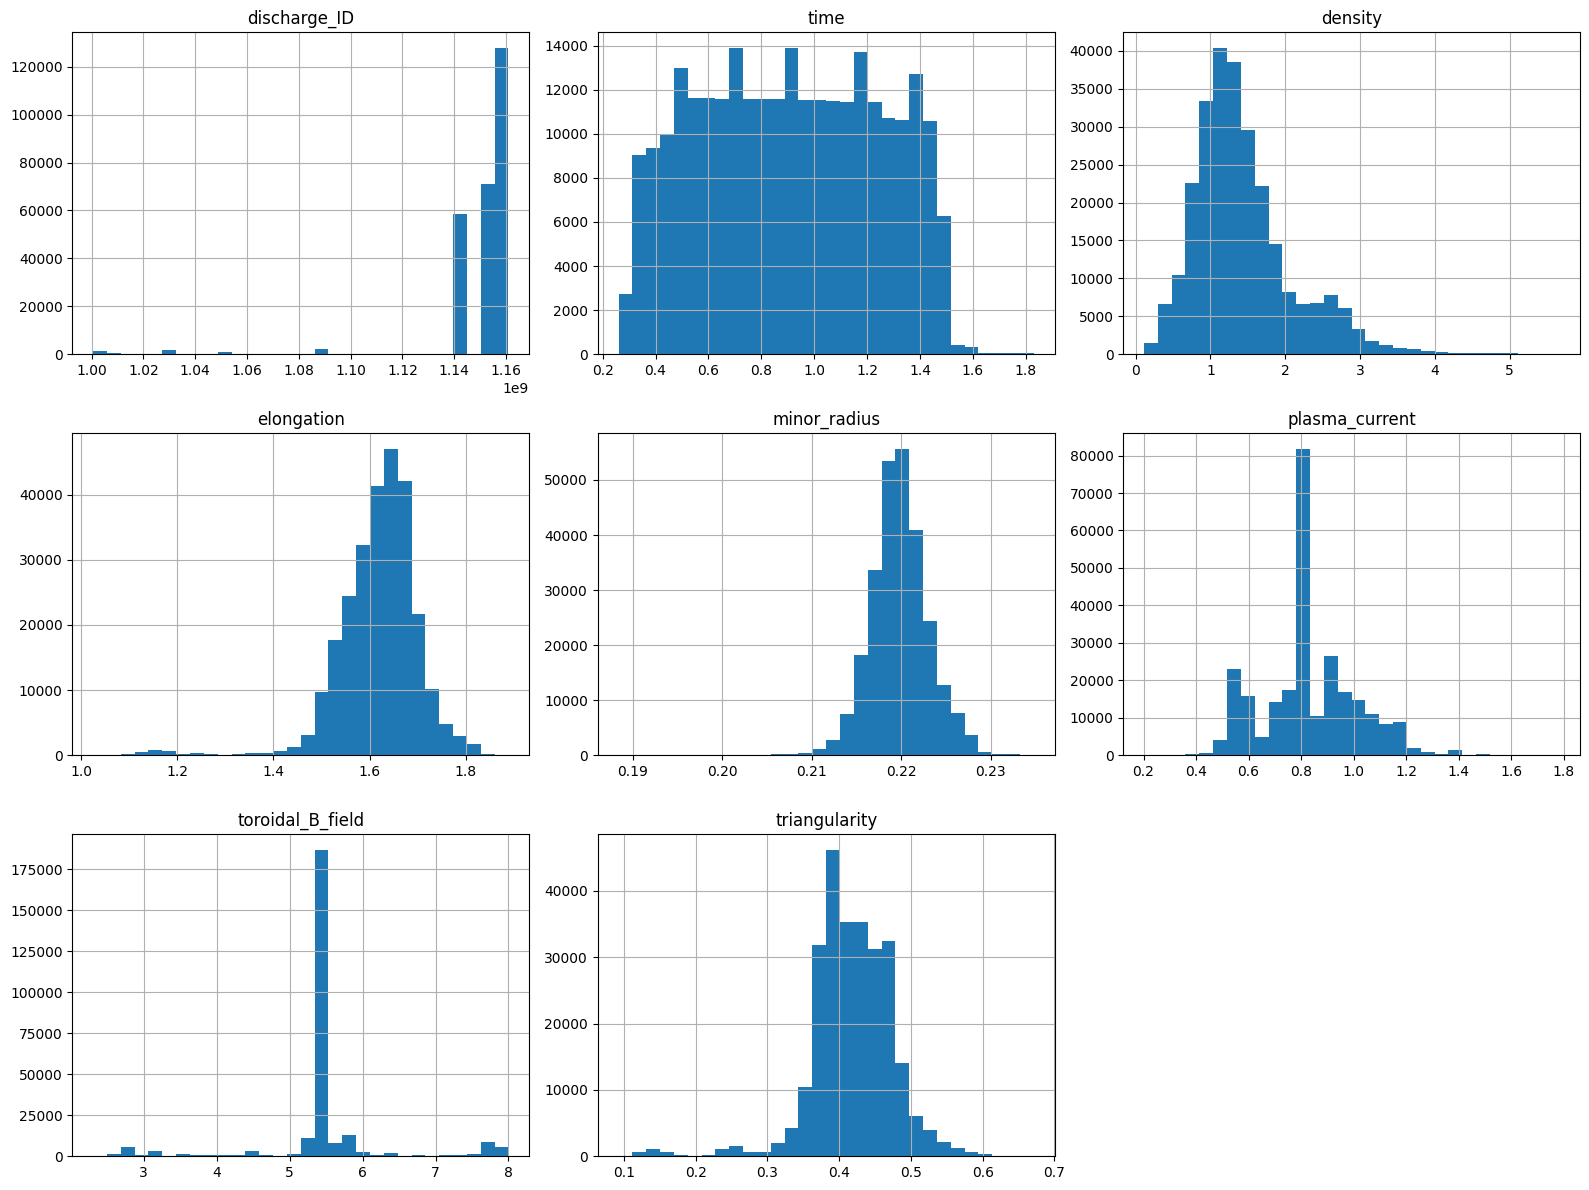

In [20]:
features = [
    'discharge_ID', 'time', 'density', 'elongation', 'minor_radius',
    'plasma_current', 'toroidal_B_field', 'triangularity'
]
target = 'density_limit_phase'

df[features].hist(bins=30, figsize=(16, 12))
plt.tight_layout()
plt.show()

Each input feature vs Density Limit Phase

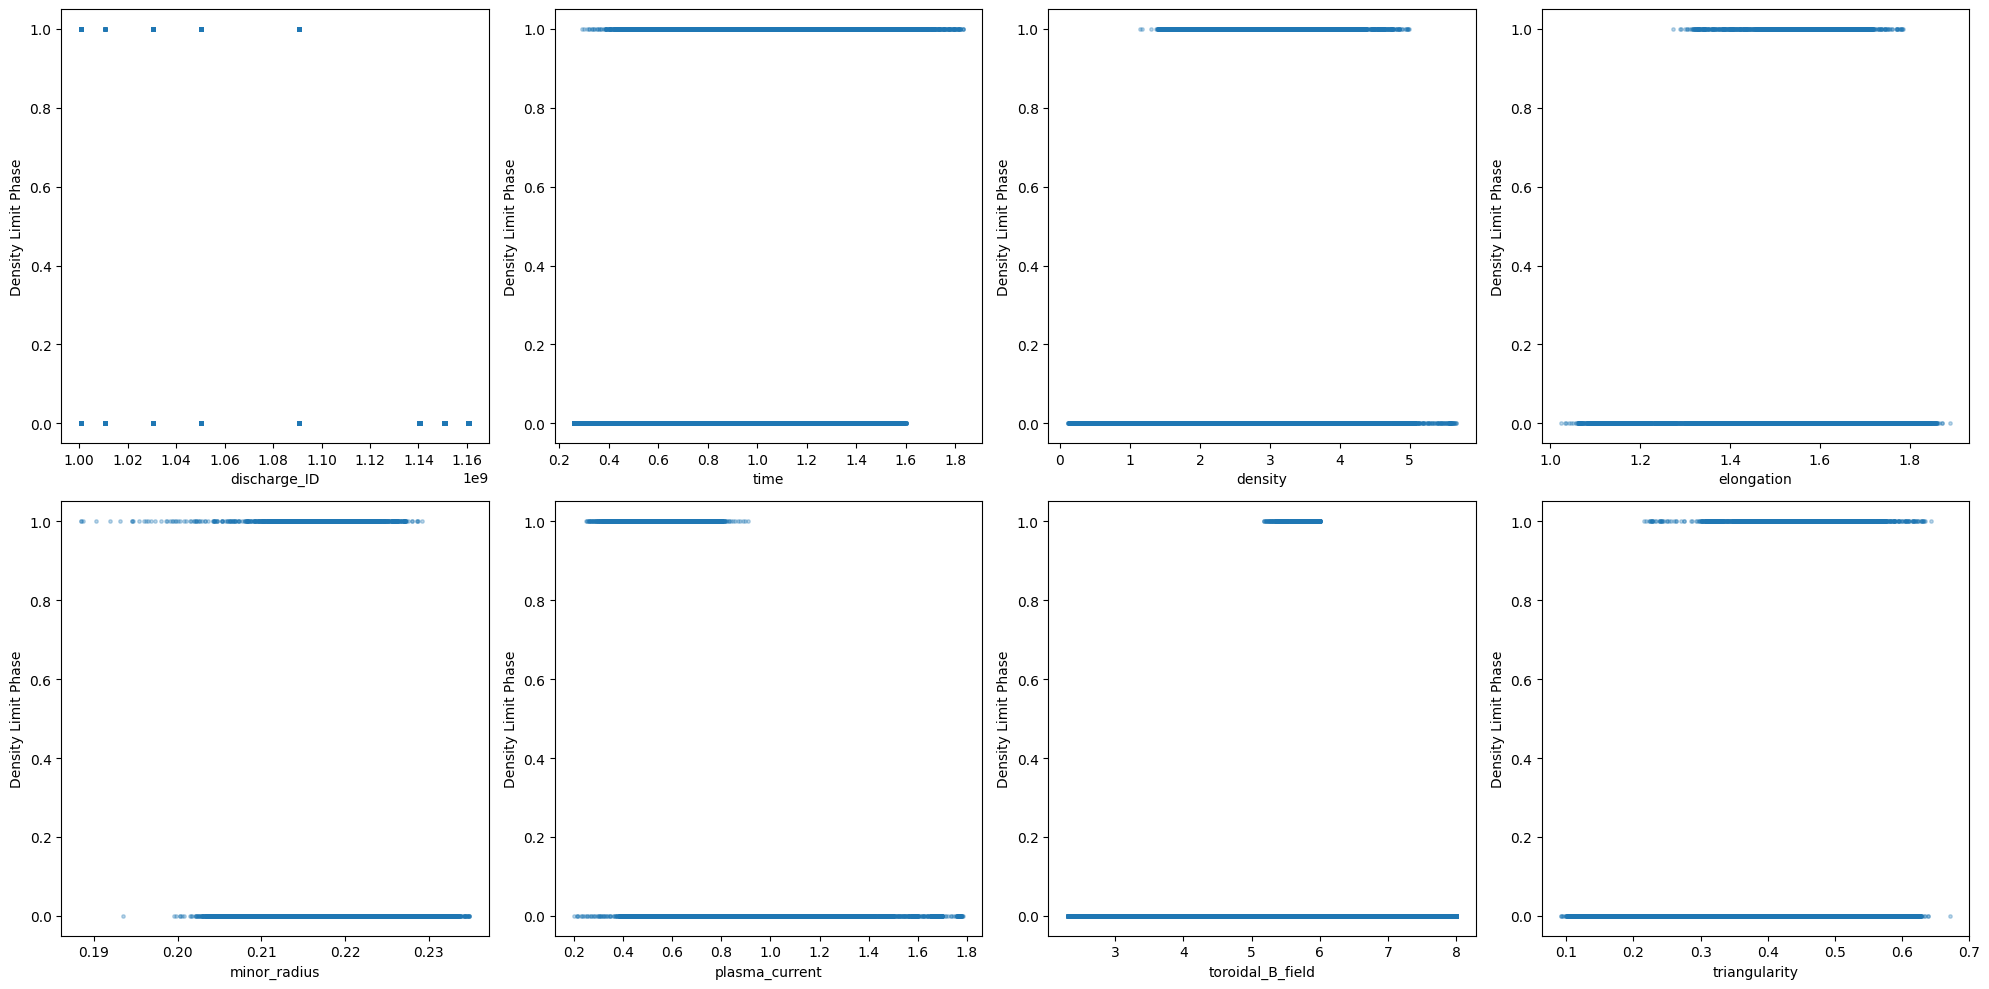

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, col in enumerate(features):
    axes[i].scatter(df[col], df[target], s=6, alpha=0.3)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density Limit Phase')

plt.tight_layout()
plt.show()

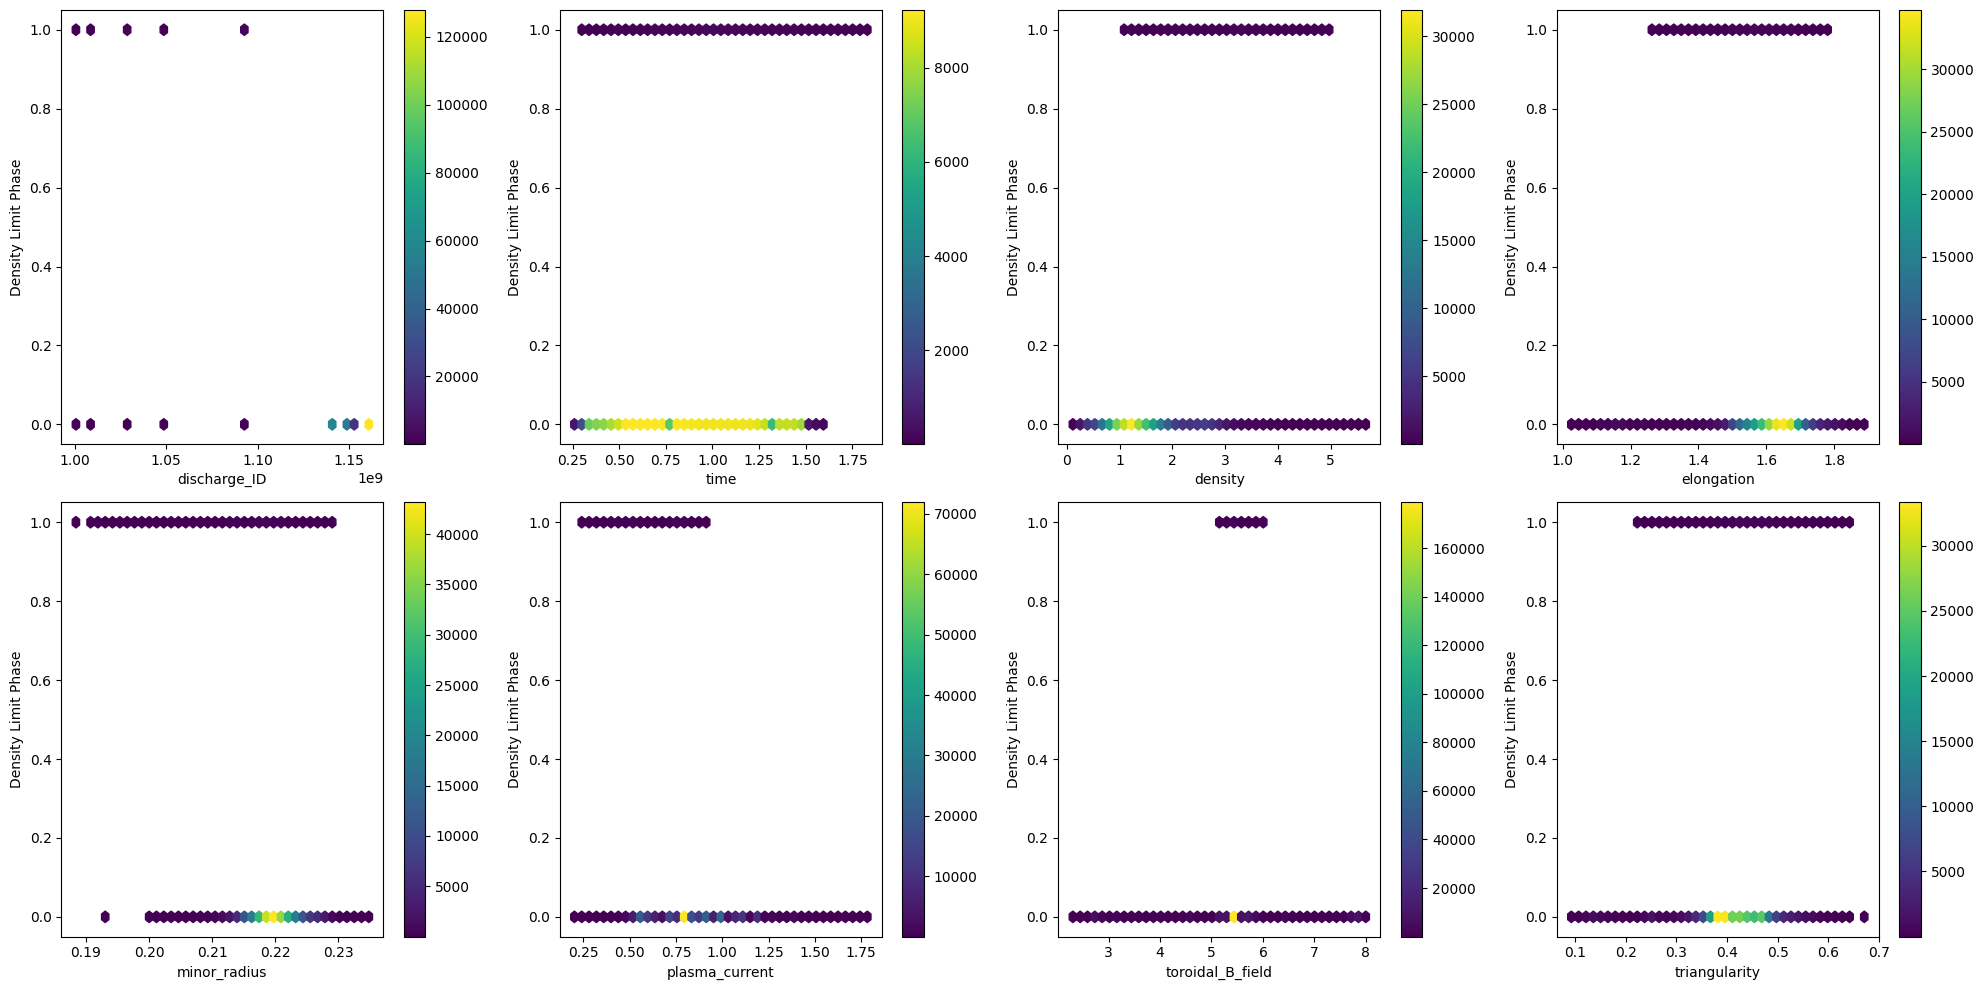

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, col in enumerate(features):
    hb = axes[i].hexbin(df[col], df[target], gridsize=40, cmap='viridis', mincnt=1)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density Limit Phase')
    fig.colorbar(hb, ax=axes[i])

plt.tight_layout()
plt.show()

Correlation heatmap

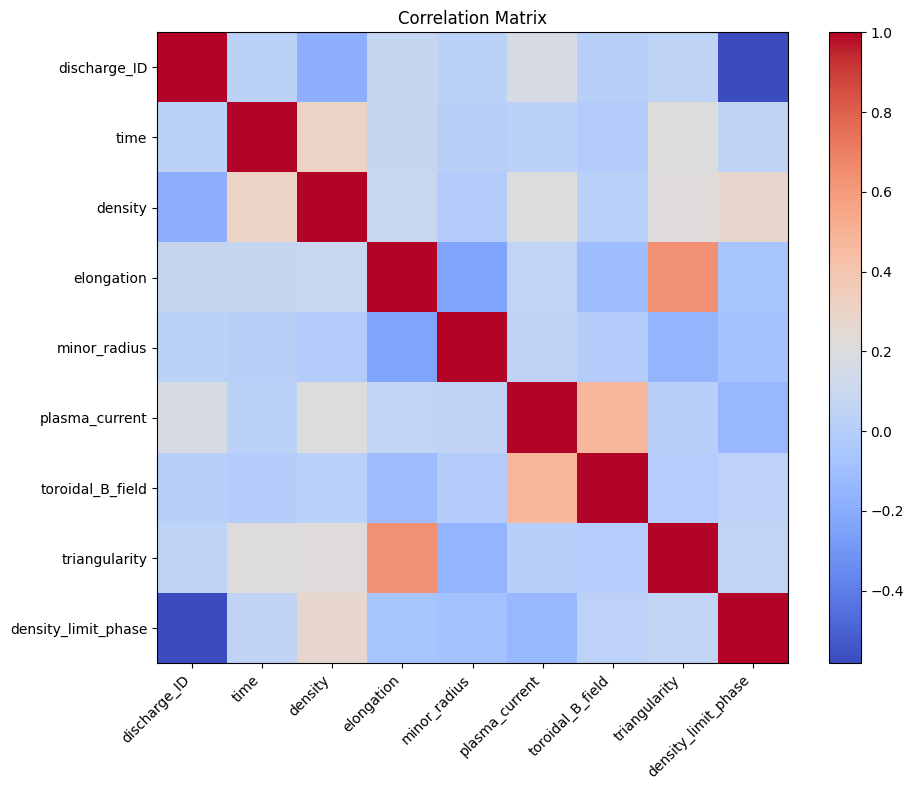

                     discharge_ID   time  density  elongation  minor_radius  \
discharge_ID                1.000  0.032   -0.182       0.081         0.035   
time                        0.032  1.000    0.307       0.085         0.015   
density                    -0.182  0.307    1.000       0.095        -0.018   
elongation                  0.081  0.085    0.095       1.000        -0.238   
minor_radius                0.035  0.015   -0.018      -0.238         1.000   
plasma_current              0.170  0.028    0.206       0.061         0.049   
toroidal_B_field            0.016 -0.007    0.018      -0.107        -0.009   
triangularity               0.047  0.207    0.217       0.637        -0.155   
density_limit_phase        -0.582  0.051    0.273      -0.065        -0.078   

                     plasma_current  toroidal_B_field  triangularity  \
discharge_ID                  0.170             0.016          0.047   
time                          0.028            -0.007          0.

In [23]:
corr = df[features + [target]].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()
print(corr.round(3))